In [1]:
# =========================================================
# 1. Imports
# =========================================================
import os
import xml.etree.ElementTree as ET
from collections import defaultdict, Counter
import cv2
import numpy as np
import pandas as pd

# --- FIX START ---
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True # This tells PIL to tolerate corrupted/truncated images
# --- FIX END ---

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

# Use seaborn aesthetics for beautiful plots
sns.set_theme(style="whitegrid", palette="muted")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
# =========================================================
# 2. XML Data Loading & Priority Extraction (ROBUST PATHS)
# =========================================================
xml_path  = "/kaggle/input/datasets/abrahametry/pneumonia6k-dataset/annotations.xml"
image_root = "/kaggle/input/datasets/abrahametry/pneumonia6k-dataset/Pneumonia_COCO-MAIN/images/default"

tree = ET.parse(xml_path)
root = tree.getroot()

# Priority mapping: Severe Disease > Mild > Normal
priority = {
    "Pneumonia with other complications": 4,
    "Pneumonia": 3,
    "Others": 2,
    "Normal": 1
}

total_annotations_count = 0
annotation_type_counter = Counter()
class_annotation_counter = Counter()

img_dict = {}

# --- NEW: List to keep track of exact missing files ---
missing_image_list = []

# Iterate over all images in the XML
for image in root.findall('image'):
    img_name = image.get('name')
    
    # Attempt 1: Exact path from XML (e.g., CXR-5444/img.JPEG)
    path_candidate_1 = os.path.join(image_root, img_name)
    
    # Attempt 2: Strip the subfolder prefix (e.g., img.JPEG)
    path_candidate_2 = os.path.join(image_root, os.path.basename(img_name))
    
    if os.path.exists(path_candidate_1):
        final_path = path_candidate_1
    elif os.path.exists(path_candidate_2):
        final_path = path_candidate_2
    else:
        # FIX: Add the missing image name to our list before skipping
        missing_image_list.append(img_name)
        continue

    img_dict[img_name] = {
        "path": final_path,
        "label": "Normal" # Default if no annotation exists
    }
    
    # Process children (tags or boxes)
    for child in image:
        label = child.get('label')
        if label:
            total_annotations_count += 1
            annotation_type_counter[child.tag] += 1
            class_annotation_counter[f"{label} ({child.tag})"] += 1
            
            current_label = img_dict[img_name]["label"]
            # Apply priority logic
            if priority.get(label, 0) > priority.get(current_label, 0):
                img_dict[img_name]["label"] = label

# Convert to DataFrame
records = [[info["path"], info["label"]] for info in img_dict.values()]
df = pd.DataFrame(records, columns=["path", "label"])

# Map to 4 Classes
label_map = {
    "Normal": 0, 
    "Others": 1, 
    "Pneumonia": 2, 
    "Pneumonia with other complications": 3
}
df["label_id"] = df["label"].map(label_map)
class_names = list(label_map.keys())

# --- NEW: Output the missing images list ---
if missing_image_list:
    print(f"\n⚠️ WARNING: {len(missing_image_list)} images referenced in the XML were not found in the Kaggle directory.")
    print("Here are the first 10 missing images:")
    for img in missing_image_list[:10]:
        print(f"  └─ {img}")
        
    # Save the full list to a text file in your Kaggle working directory
    with open("missing_images_list.txt", "w") as f:
        for img in missing_image_list:
            f.write(f"{img}\n")
    print(f"✅ Full list of all {len(missing_image_list)} missing images saved to 'missing_images_list.txt'")


════════════════════════════════════════════════════════════
📊 IN-DEPTH XML DATASET STATISTICS
════════════════════════════════════════════════════════════
Total Images in Dataset: 6000
Total Raw Annotations (Tags + Boxes): 6055
  └─ Normal (tag): 5193
  └─ Pneumonia (box): 314
  └─ Others (tag): 310
  └─ Pneumonia with other complications (box): 238

📈 UNIQUE CLASS DISTRIBUTION (After Priority Resolution)
  └─ Normal: 5266 images (87.77%)
  └─ Others: 308 images (5.13%)
  └─ Pneumonia: 251 images (4.18%)
  └─ Pneumonia with other complications: 175 images (2.92%)

🗂️ DATA SPLITTING (Train / Validation)
  └─ Training Set:   4800 images (80.0%)
  └─ Validation Set: 1200 images (20.0%)

Class-wise Training Split:
  └─ Normal: 4213 train | 1053 val
  └─ Others: 246 train | 62 val
  └─ Pneumonia: 201 train | 50 val
  └─ Pneumonia with other complications: 140 train | 35 val
════════════════════════════════════════════════════════════

[INFO] Initializing DenseNet121...
Downloading: "https

100%|██████████| 30.8M/30.8M [00:00<00:00, 129MB/s]


Epoch 01/20 | Train Loss: 1.3998 | Train Acc: 32.83% | Val Loss: 0.8945 | Val Acc: 74.58% -> ✔ Best model saved
Epoch 02/20 | Train Loss: 1.3337 | Train Acc: 37.98% | Val Loss: 0.9100 | Val Acc: 70.25%
Epoch 03/20 | Train Loss: 1.3265 | Train Acc: 39.54% | Val Loss: 1.1035 | Val Acc: 61.75%
Epoch 04/20 | Train Loss: 1.3195 | Train Acc: 39.71% | Val Loss: 0.9466 | Val Acc: 70.83%
Epoch 05/20 | Train Loss: 1.3251 | Train Acc: 39.04% | Val Loss: 1.0696 | Val Acc: 58.33%
Epoch 06/20 | Train Loss: 1.3300 | Train Acc: 38.67% | Val Loss: 1.5227 | Val Acc: 32.58%
Epoch 07/20 | Train Loss: 1.3251 | Train Acc: 38.92% | Val Loss: 0.7143 | Val Acc: 79.75% -> ✔ Best model saved
Epoch 08/20 | Train Loss: 1.3181 | Train Acc: 39.96% | Val Loss: 1.2912 | Val Acc: 45.00%
Epoch 09/20 | Train Loss: 1.3319 | Train Acc: 38.46% | Val Loss: 0.8869 | Val Acc: 67.67%
Epoch 10/20 | Train Loss: 1.3260 | Train Acc: 38.38% | Val Loss: 0.9143 | Val Acc: 65.42%

[INFO] Unfreezing denseblock4 of DenseNet for fine-tuni

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


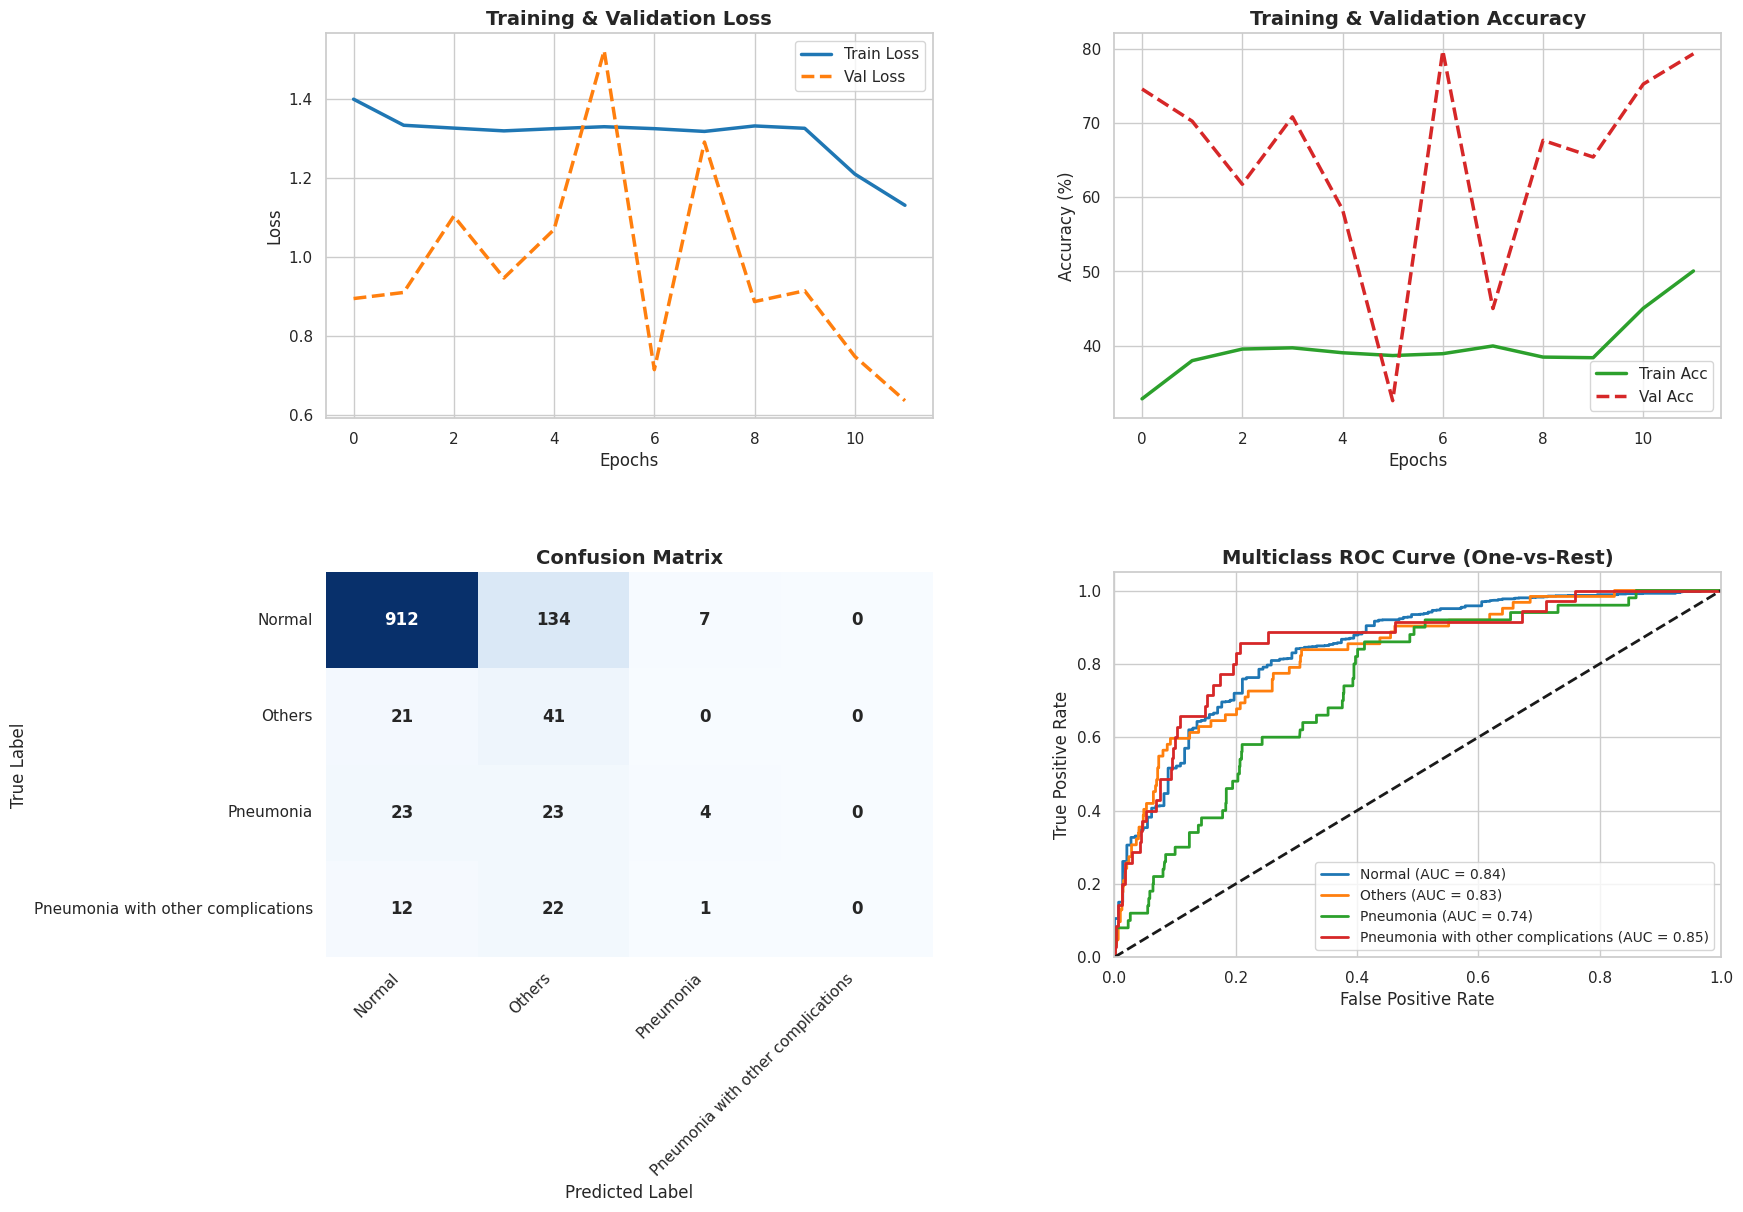

In [3]:
# =========================================================
# 2. XML Data Loading & Priority Extraction (ROBUST PATHS)
# =========================================================
xml_path  = "/kaggle/input/datasets/abrahametry/pneumonia6k-dataset/annotations.xml"
image_root = "/kaggle/input/datasets/abrahametry/pneumonia6k-dataset/Pneumonia_COCO-MAIN/images/default"

tree = ET.parse(xml_path)
root = tree.getroot()

# Priority mapping: Severe Disease > Mild > Normal
priority = {
    "Pneumonia with other complications": 4,
    "Pneumonia": 3,
    "Others": 2,
    "Normal": 1
}

total_annotations_count = 0
annotation_type_counter = Counter()
class_annotation_counter = Counter()

img_dict = {}
missing_images = 0

# Iterate over all images in the XML
for image in root.findall('image'):
    img_name = image.get('name')
    
    # --- FIX: Robust File Path Resolution ---
    # Attempt 1: Exact path from XML (e.g., images/default/CXR-5444/img.JPEG)
    path_candidate_1 = os.path.join(image_root, img_name)
    
    # Attempt 2: Strip the subfolder prefix (e.g., images/default/img.JPEG)
    path_candidate_2 = os.path.join(image_root, os.path.basename(img_name))
    
    if os.path.exists(path_candidate_1):
        final_path = path_candidate_1
    elif os.path.exists(path_candidate_2):
        final_path = path_candidate_2
    else:
        # If the image truly isn't in the dataset folder, skip it gracefully
        missing_images += 1
        continue
    # ----------------------------------------

    img_dict[img_name] = {
        "path": final_path,
        "label": "Normal" # Default if no annotation exists
    }
    
    # Process children (tags or boxes)
    for child in image:
        label = child.get('label')
        if label:
            total_annotations_count += 1
            annotation_type_counter[child.tag] += 1
            class_annotation_counter[f"{label} ({child.tag})"] += 1
            
            current_label = img_dict[img_name]["label"]
            # Apply priority logic
            if priority.get(label, 0) > priority.get(current_label, 0):
                img_dict[img_name]["label"] = label

# Convert to DataFrame
records = [[info["path"], info["label"]] for info in img_dict.values()]
df = pd.DataFrame(records, columns=["path", "label"])

# Map to 4 Classes
label_map = {
    "Normal": 0, 
    "Others": 1, 
    "Pneumonia": 2, 
    "Pneumonia with other complications": 3
}
df["label_id"] = df["label"].map(label_map)
class_names = list(label_map.keys())

if missing_images > 0:
    print(f"⚠️ WARNING: {missing_images} images referenced in the XML were not found in the Kaggle directory and were skipped.")

# =========================================================
# 3. Train/Test Split
# =========================================================
train_df, val_df = train_test_split(
    df, test_size=0.2, stratify=df["label_id"], random_state=42
)

# =========================================================
# 4. In-Depth Dataset Statistics Breakdown
# =========================================================
print("\n" + "═"*60)
print("📊 IN-DEPTH XML DATASET STATISTICS")
print("═"*60)

total_images = len(df)
train_count = len(train_df)
val_count = len(val_df)

print(f"Total Images in Dataset: {total_images}")
print(f"Total Raw Annotations (Tags + Boxes): {total_annotations_count}")
for ann_type, count in class_annotation_counter.items():
    print(f"  └─ {ann_type}: {count}")

print("\n📈 UNIQUE CLASS DISTRIBUTION (After Priority Resolution)")
dist = df["label"].value_counts()
for name, count in dist.items():
    percentage = (count / total_images) * 100
    print(f"  └─ {name}: {count} images ({percentage:.2f}%)")

print("\n🗂️ DATA SPLITTING (Train / Validation)")
print(f"  └─ Training Set:   {train_count} images ({train_count/total_images*100:.1f}%)")
print(f"  └─ Validation Set: {val_count} images ({val_count/total_images*100:.1f}%)")

print("\nClass-wise Training Split:")
for label, count in train_df["label"].value_counts().items():
    print(f"  └─ {label}: {count} train | {val_df[val_df['label'] == label].shape[0]} val")
print("═"*60 + "\n")

# =========================================================
# 5. Image Processing & Dataloaders
# =========================================================
def apply_clahe(img):
    img = np.array(img)
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    cl = clahe.apply(l)
    limg = cv2.merge((cl, a, b))
    img = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)
    return Image.fromarray(img)

train_transform = transforms.Compose([
    transforms.Resize((384, 384)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10), 
    transforms.ColorJitter(brightness=0.2, contrast=0.2), 
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.1)) 
])

val_transform = transforms.Compose([
    transforms.Resize((384, 384)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

class CXRDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "path"]
        label = self.df.loc[idx, "label_id"]
        image = Image.open(img_path).convert("RGB")
        image = apply_clahe(image)
        if self.transform:
            image = self.transform(image)
        return image, label

train_dataset = CXRDataset(train_df, train_transform)
val_dataset = CXRDataset(val_df, val_transform)

# --- CLASS IMBALANCE HANDLING (Safe Division) ---
class_counts = np.bincount(train_df["label_id"].values, minlength=4)
weights = np.where(class_counts > 0, 1.0 / class_counts, 0.0)
weights = torch.tensor(weights, dtype=torch.float)

sample_weights = [weights[label] for label in train_df["label_id"]]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

train_loader = DataLoader(train_dataset, batch_size=16, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

# =========================================================
# 6. DenseNet121 Model Setup
# =========================================================
print("[INFO] Initializing DenseNet121...")
model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)

# Freeze all layers initially
for param in model.parameters():
    param.requires_grad = False

# Replace classifier for 4 classes
num_ftrs = model.classifier.in_features
model.classifier = nn.Sequential(
    nn.Dropout(0.6),
    nn.Linear(num_ftrs, 4)
)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW([
    {'params': model.classifier.parameters(), 'lr': 1e-3}
], weight_decay=1e-3)

# =========================================================
# 7. Training Setup
# =========================================================
epochs = 20
freeze_epochs = 10 
best_val_acc = 0
patience = 5
counter = 0

train_losses, val_losses, train_accs, val_accs = [], [], [], []

# =========================================================
# 8. Two-Phase Training Loop
# =========================================================
for epoch in range(epochs):
    
    # --- PHASE 2 TRANSITION FOR DENSENET ---
    if epoch == freeze_epochs:
        print("\n[INFO] Unfreezing denseblock4 of DenseNet for fine-tuning...")
        # Unfreeze the last dense block and norm layer
        for param in model.features.denseblock4.parameters():
            param.requires_grad = True
        for param in model.features.norm5.parameters():
            param.requires_grad = True
            
        optimizer.param_groups[0]['lr'] = 1e-4
        optimizer.add_param_group({
            'params': list(model.features.denseblock4.parameters()) + list(model.features.norm5.parameters()), 
            'lr': 5e-5, 
            'weight_decay': 1e-2
        })
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.3, patience=3)

    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = train_loss / len(train_loader)
    train_acc = 100 * correct / total

    # Validation
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss / len(val_loader)
    val_acc = 100 * val_correct / val_total

    if epoch >= freeze_epochs:
        scheduler.step(val_acc)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1:02d}/{epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%", end="")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")
        counter = 0
        print(" -> ✔ Best model saved")
    else:
        counter += 1
        print("")
        if counter >= patience and epoch >= freeze_epochs:
            print("\n[INFO] Early stopping triggered")
            break

# =========================================================
# 9. Load Best Model & Compute Predictions/Probabilities
# =========================================================
print("\n[INFO] Loading best model for evaluation...")
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

y_true, y_pred, y_probs = [], [], []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        
        # Softmax for ROC Curve probabilities
        probs = torch.nn.functional.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
        
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        y_probs.extend(probs.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_probs = np.array(y_probs)

# =========================================================
# 10. Elegant Visualizations
# =========================================================

# A. Elegant Classification Report Table
print("\n" + "═"*60)
print("📄 CLASSIFICATION REPORT")
print("═"*60)
report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose().round(3)
# Format display nicely
print(report_df.to_string())
print("═"*60 + "\n")

# Setup Matplotlib Figure Grid
fig = plt.figure(figsize=(18, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# B. Training Curves (Loss & Accuracy)
ax1 = plt.subplot(2, 2, 1)
ax1.plot(train_losses, label="Train Loss", color="#1f77b4", linewidth=2.5)
ax1.plot(val_losses, label="Val Loss", color="#ff7f0e", linewidth=2.5, linestyle="--")
ax1.set_title("Training & Validation Loss", fontsize=14, fontweight='bold')
ax1.set_xlabel("Epochs", fontsize=12)
ax1.set_ylabel("Loss", fontsize=12)
ax1.legend(loc="upper right", frameon=True)

ax2 = plt.subplot(2, 2, 2)
ax2.plot(train_accs, label="Train Acc", color="#2ca02c", linewidth=2.5)
ax2.plot(val_accs, label="Val Acc", color="#d62728", linewidth=2.5, linestyle="--")
ax2.set_title("Training & Validation Accuracy", fontsize=14, fontweight='bold')
ax2.set_xlabel("Epochs", fontsize=12)
ax2.set_ylabel("Accuracy (%)", fontsize=12)
ax2.legend(loc="lower right", frameon=True)

# C. Elegant Confusion Matrix
ax3 = plt.subplot(2, 2, 3)
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=class_names, yticklabels=class_names, 
            annot_kws={"size": 12, "weight": "bold"}, ax=ax3)
ax3.set_title("Confusion Matrix", fontsize=14, fontweight='bold')
ax3.set_xlabel("Predicted Label", fontsize=12)
ax3.set_ylabel("True Label", fontsize=12)
plt.setp(ax3.get_xticklabels(), rotation=45, ha="right")

# D. Multiclass ROC Curve (One-vs-Rest)
ax4 = plt.subplot(2, 2, 4)
y_true_bin = label_binarize(y_true, classes=[0, 1, 2, 3])
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, color in zip(range(4), colors):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc = auc(fpr, tpr)
    ax4.plot(fpr, tpr, color=color, lw=2,
             label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

ax4.plot([0, 1], [0, 1], 'k--', lw=2)
ax4.set_xlim([0.0, 1.0])
ax4.set_ylim([0.0, 1.05])
ax4.set_xlabel('False Positive Rate', fontsize=12)
ax4.set_ylabel('True Positive Rate', fontsize=12)
ax4.set_title('Multiclass ROC Curve (One-vs-Rest)', fontsize=14, fontweight='bold')
ax4.legend(loc="lower right", fontsize=10, frameon=True)

plt.show()